# Day 08. Exercise 04
# Regression

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [2]:
df = pd.read_csv("checker_regression.csv")
print(df.shape)
df.head()

(77, 4)


,uid,num_commits,pageviews,AVG(diff)
0,user_1,62,28.0,NaN
1,user_1,62,28.0,NaN
2,user_1,62,28.0,NaN
3,user_1,62,28.0,NaN
4,user_1,62,28.0,NaN


In [3]:
df.isna().sum()

uid             0
num_commits     0
pageviews      18
AVG(diff)      59
dtype: int64

In [4]:
df = df.groupby('uid').first().fillna(0)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, user_1 to user_8
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   num_commits  29 non-null     int64  
 1   pageviews    29 non-null     float64
 2   AVG(diff)    29 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 928.0+ bytes


In [5]:
X = df.drop('AVG(diff)', axis=1)
y = df['AVG(diff)']
test_size=0.2
random_state=21

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (23, 2)
y_train shape: (23,)
X_test shape: (6, 2)
y_test shape: (6,)


## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

In [6]:
def crossval(n_splits, X, y, model):
  kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
  rmse = []
  for train, test in kf.split(X, y):
    X_train, X_test = X.iloc[train], X.iloc[test]
    y_train, y_test = y.iloc[train], y.iloc[test]
    model.fit(X_train, y_train)
    rmse_train = root_mean_squared_error(y_train, model.predict(X_train))
    rmse_test = root_mean_squared_error(y_test, model.predict(X_test))
    rmse.append(rmse_test)
    print(f'train - {rmse_train}\t| test - {rmse_test}')
  print(f'average RMSE - {np.mean(rmse)}')

In [7]:
model1 = LinearRegression()
model2 = DecisionTreeRegressor()
model3 = RandomForestRegressor()

In [8]:
crossval(10, X, y, model1)

train - 61.35327112662008	| test - 57.85614740884658
train - 62.5462335194863	| test - 44.71218893425673
train - 61.14556371253599	| test - 83.19897138394585
train - 58.416728626194235	| test - 79.399015977114
train - 60.11026827841826	| test - 68.756146189296
train - 60.619323028395335	| test - 65.92296908962915
train - 61.72075104991357	| test - 61.800360553015715
train - 62.60680682836641	| test - 46.68994292992783
train - 55.58034321272078	| test - 99.08124434288634
train - 61.577932451061805	| test - 53.24118830442656
average RMSE - 66.06581751133447


In [9]:
crossval(10, X, y, model2)

train - 0.0	| test - 117.17718934888181
train - 0.0	| test - 79.5333147061541


train - 0.0	| test - 0.0
train - 0.0	| test - 78.98656472722058
train - 0.0	| test - 101.36705213854874
train - 0.0	| test - 35.38836908740875
train - 0.0	| test - 0.0
train - 0.0	| test - 69.81014730443323
train - 0.0	| test - 117.52949078296776
train - 0.0	| test - 40.58792924010783
average RMSE - 64.03800573357229


In [10]:
crossval(10, X, y, model3)

train - 21.21697514756505	| test - 94.92504286521533
train - 23.87048569907231	| test - 80.08807189541983
train - 26.368807669747685	| test - 25.26677228063532
train - 25.14745073512277	| test - 61.50856204356163
train - 22.01289168286284	| test - 83.77916038344831
train - 25.13171399441367	| test - 61.196128702297386
train - 24.71886898294377	| test - 4.127055366723349
train - 24.161654262594013	| test - 58.697953833035605
train - 20.527161304530683	| test - 88.70160019768318
train - 25.732900250105757	| test - 30.751253991594453
average RMSE - 58.904160155961435


## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

In [11]:
res_df = y_test.copy().to_frame(name='actual')

pred_model1 = model1.predict(X_test)
rmse_model1 = root_mean_squared_error(pred_model1, y_test)
print("model1: ", rmse_model1)
res_df['model1'] = pred_model1

pred_model2 = model2.predict(X_test)
rmse_model2 = root_mean_squared_error(pred_model2, y_test)
print("model2: ", rmse_model2)
res_df['model2'] = pred_model2

pred_model3 = model3.predict(X_test)
rmse_model3 = root_mean_squared_error(pred_model3, y_test)
print("model3: ", rmse_model3)
res_df['mode13'] = pred_model3

model1:  50.28209649353397
model2:  0.0
model3:  33.36153965521778


In [12]:
print(res_df)

             actual     model1      model2      mode13
uid                                                   
user_26  -52.333333 -72.710565  -52.333333 -101.214000
user_29 -157.400000 -71.126381 -157.400000 -127.725000
user_10    0.000000 -40.895567    0.000000    0.000000
user_2  -137.200000 -71.654442 -137.200000 -111.374667
user_14    0.000000 -16.236713    0.000000    0.000000
user_16  -39.333333 -72.182503  -39.333333  -91.688667


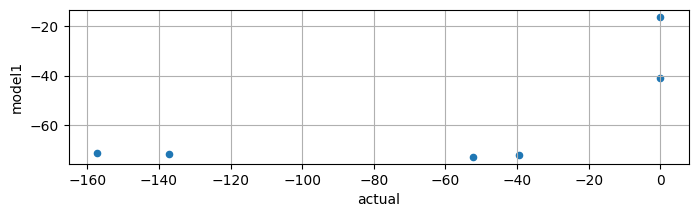

In [13]:
res_df.plot.scatter(x='actual', y='model1', figsize=(8,2))
plt.grid()

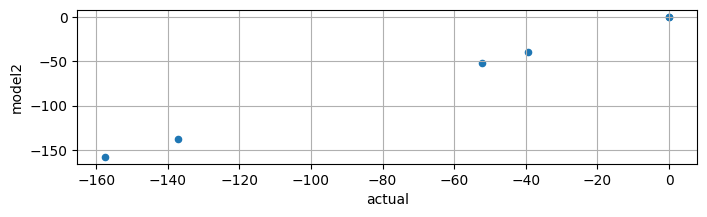

In [14]:
res_df.plot.scatter(x='actual', y='model2', figsize=(8,2))
plt.grid()

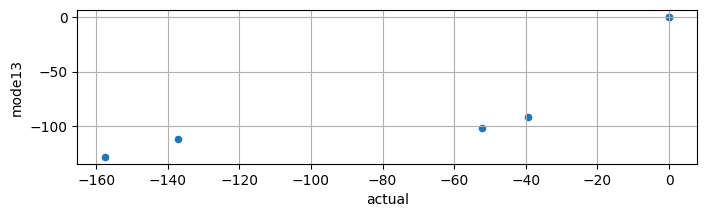

In [15]:
res_df.plot.scatter(x='actual', y='mode13', figsize=(8,2))
plt.grid()

Diagonal